In [177]:
'''
Plot the membrane traces for a specific trial so
that we may understand what is actually going on. 

'''

'\nPlot the membrane traces for a specific trial so\nthat we may understand what is actually going on. \n\n'

In [178]:
import aqua

from aqua.batchAQUA_general import batchAQUA
from aqua.utils import *
from aqua.stimulus import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import convolve, windows
from scipy.ndimage import gaussian_filter
import scipy.stats as stats
from tqdm import tqdm
import pickle
import seaborn as sns
sns.set_theme()

from CPA_with_AQUA import *

from changepoynt.algorithms.fluss import FLUSS


RS = {'name': 'RS_ref', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
     'a': 0.03, 'b': -2, 'c': -50, 'd': 100, 'e': 0.2, 'f': 0., 'tau': 2.}

In [179]:
def find_idx(f, v, h, f_vals, v_vals, h_vals):
    # finds the index of a given set of parameters values
    # given the list of those parameter values which the 
    # defined the population simulations.
    N_f = len(f_vals)
    N_v = len(v_vals)
    N_h = len(h_vals)

    idx_f = np.argwhere(f_vals == f)[0][0]
    idx_v = np.argwhere(v_vals == v)[0][0]
    idx_h = np.argwhere(h_vals == h)[0][0]

    idx = idx_v * (N_f*N_h) + idx_h * N_f + idx_f

    return int(idx)

In [180]:
# Just re-simulate the the traces...
'''neuron parameters'''
f_values = np.array([200, 225, 260, 280, 300, 350, 400])
model = RS
d_H = np.array([0, 1, 2, 3, 4, 5, 10, 12, 15, 18]) #, 20, 25, 30, 40, 50])
var = np.array([0, 12.5])       # no noise


T = 3000 # ms
dt = 0.1
N_iter = int(T/dt)

# create parameter dictionary
params = []
#params.append(model)    # add the non-autaptic neuron
e = 0.2     # /ms
tau = 2.0   # ms

for f in f_values:
    temp_dict = model.copy()
    temp_dict['e'] = e
    temp_dict['tau'] = tau
    temp_dict['f'] = np.round(f, 2)
    params.append(temp_dict)

params_df = pd.DataFrame(params)
f_vals = params_df['f'].to_numpy()

N_neurons = len(params)


N_sims = N_neurons * len(d_H) * len(var)
print(f'N_SIMS: {N_sims}')

I_0 = 60    # pA, initial driving current
changepoint = 1500 # ms
noise_rate = 50 # Hz
noise_steps = int(1/noise_rate * (1000/dt))
num_unique = N_iter // noise_steps      # number of random numbers to sample
I_inj = np.zeros((N_sims, N_iter))
N_p_var = N_neurons * len(d_H)  # number of iterations per var


sim_params = []
for l, v in enumerate(var):
    for m, h in enumerate(d_H):
        step = np.array([step_current(N_iter, dt, y_0 = I_0, delay = changepoint, I_h = I_0 + h) for i in range(N_neurons)])
        unique_samples = np.random.normal(loc = 0.0, scale = np.sqrt(v), size = num_unique)
        WN = np.repeat(unique_samples, noise_steps)
        step_w_noise = step + WN
        idx = l * N_p_var + m * N_neurons
        I_inj[idx:idx+N_neurons, :] = step_w_noise
        sim_params.append(params)
sim_params = list(np.array(sim_params).flatten())
params_df = pd.DataFrame(sim_params)
print(len(params_df))

# start values        
x_start = np.full((N_sims, 3), fill_value = np.array([-60, 0, 0]))
t_start = np.zeros(N_sims)

# create batch and initialise
batch = batchAQUA(params_df)
batch.Initialise(x_start, t_start)

# simulate
X, t, spikes =  batch.update_batch(dt, N_iter, I_inj)

N_SIMS: 140
140


  0%|          | 0/29999 [00:00<?, ?it/s]

100%|██████████| 29999/29999 [00:04<00:00, 6955.38it/s]


N_neurons: 7
X: (140, 3, 30000)


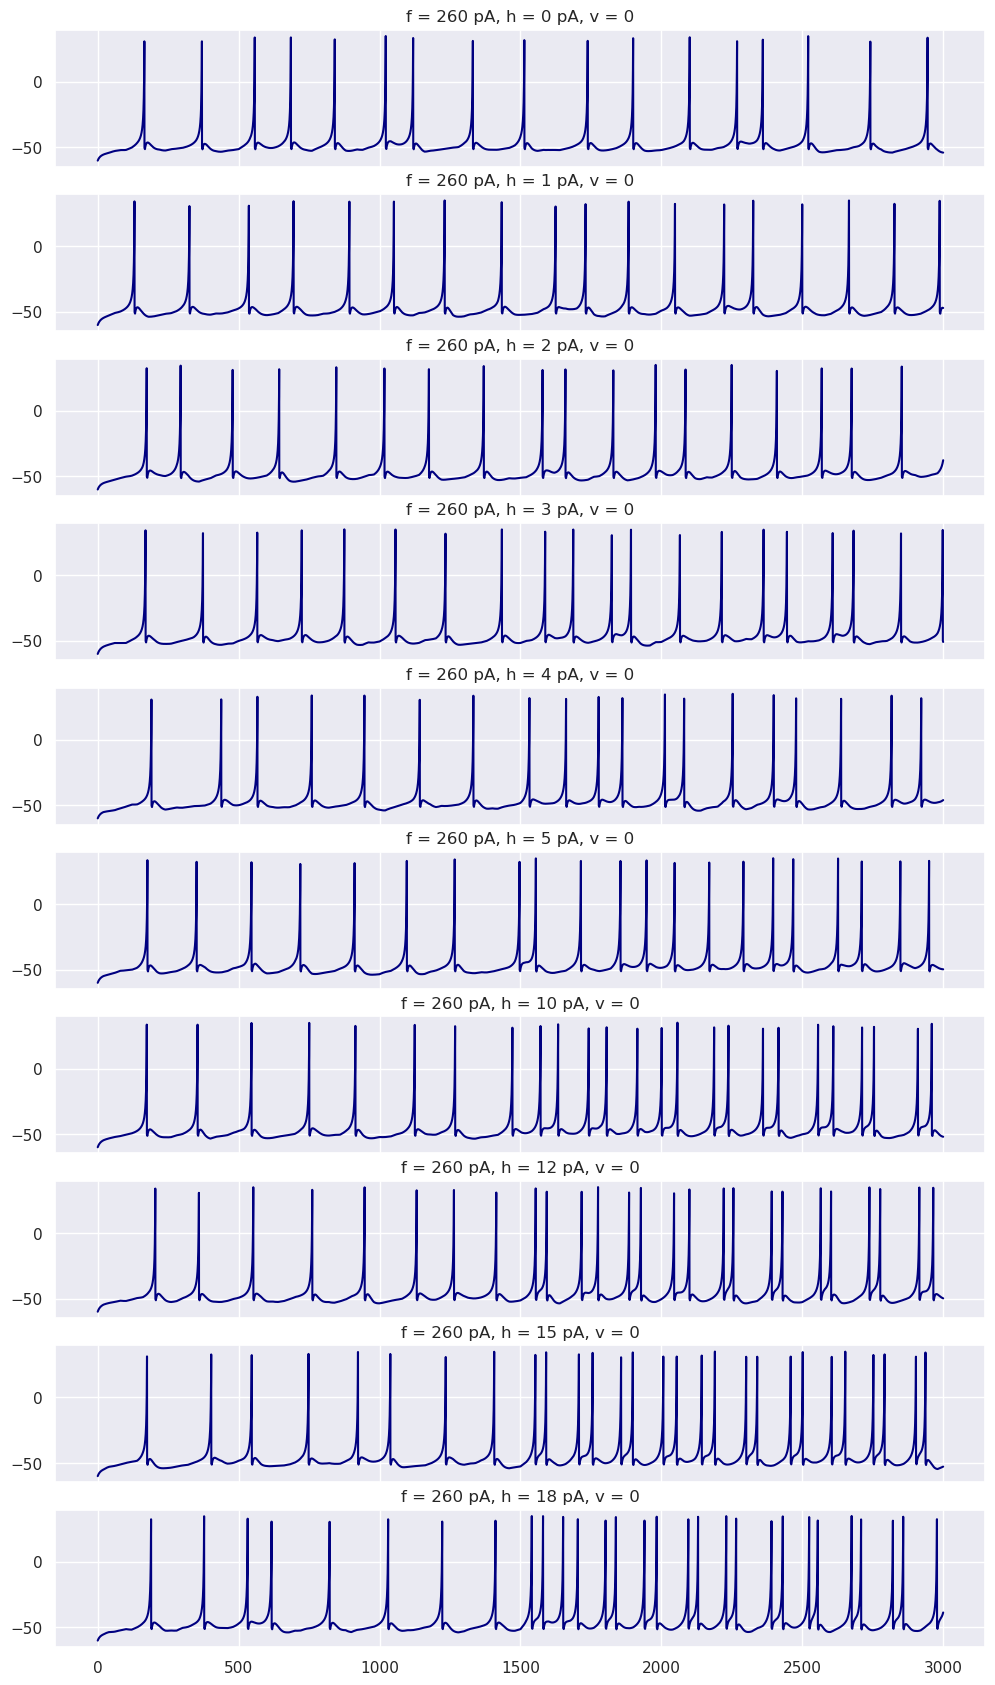

In [ ]:
## Plot X 

print(f'N_neurons: {N_neurons}')
print(f'X: {np.shape(X)}')
fluss_detector = FLUSS(window_length = 300)

fig, ax = plt.subplots(len(d_H), 1, figsize = (12, 3*N_neurons), sharex = 'col')
f_target = 400
v_target = 12.5
for n, h in enumerate(d_H):

    idx = find_idx(f_target, v_target, h, f_values, var, d_H)
    ax[n].plot(t, X[idx, 0, :], c = 'navy')
    ax[n].set_title(f'f = {f_target} pA, h = {h} pA, v = {v_target}')



N_neurons: 7
X: (140, 3, 30000)


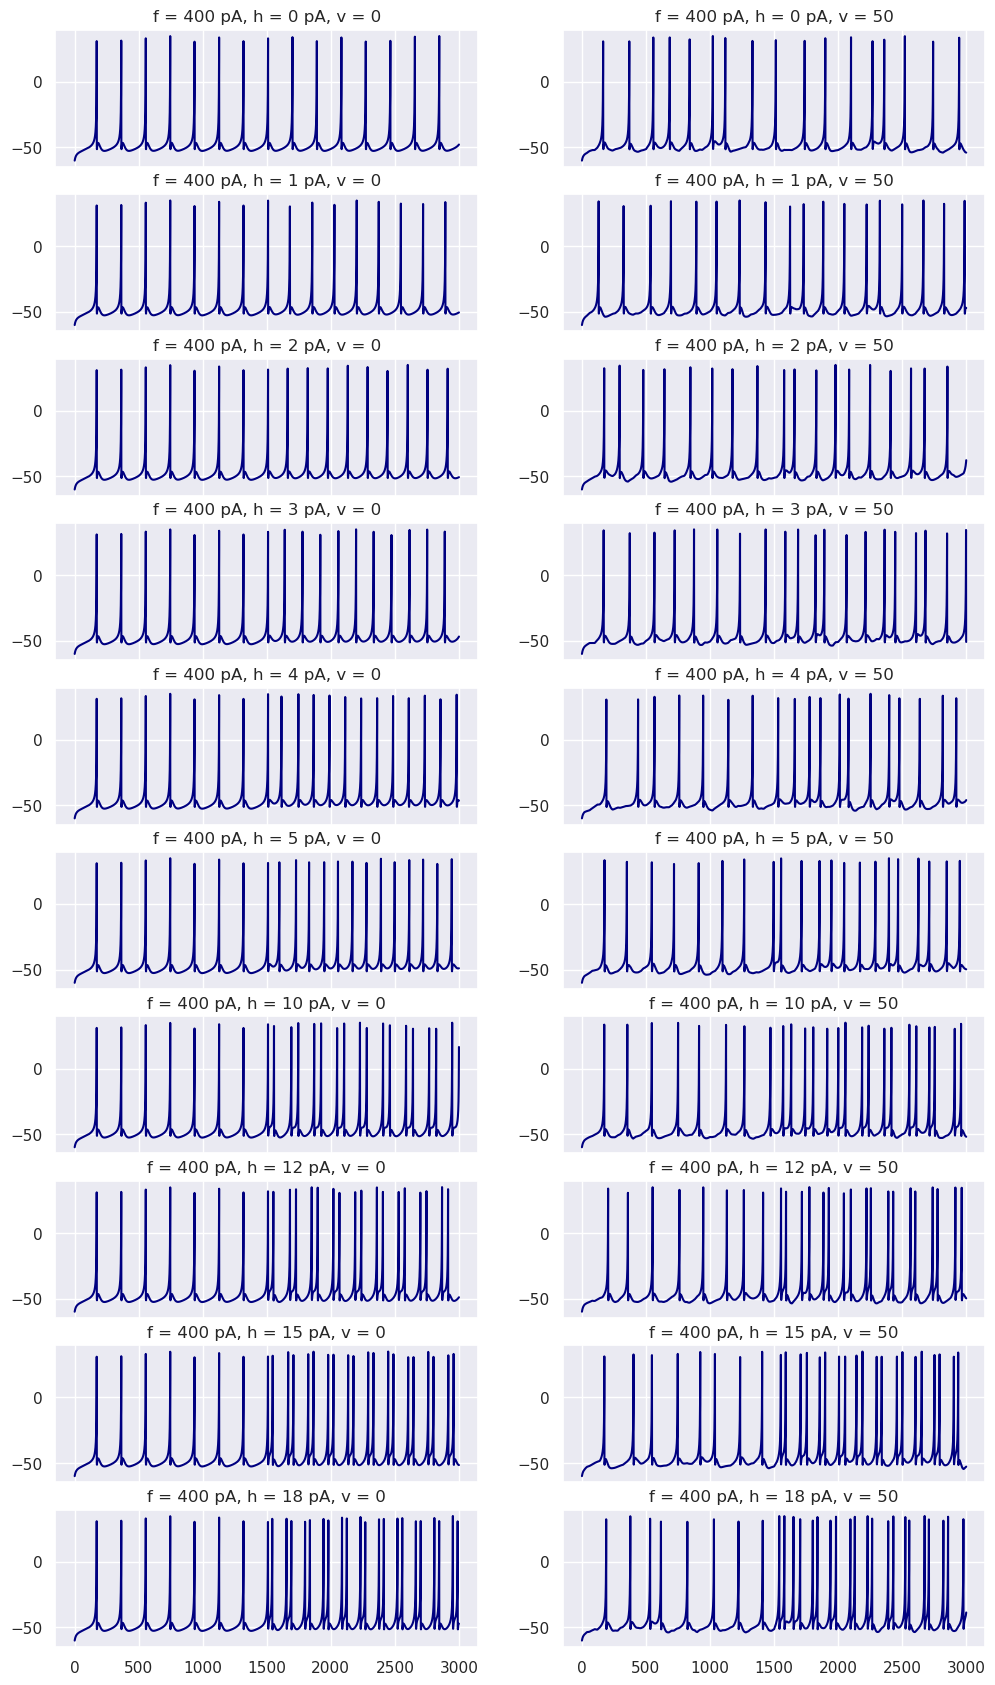

In [ ]:
## Plot X 

print(f'N_neurons: {N_neurons}')
print(f'X: {np.shape(X)}')
fluss_detector = FLUSS(window_length = 300)

fig, ax = plt.subplots(len(d_H), 2, figsize = (12, 3*N_neurons), sharex = 'col')
f_target = 400
v_target = 12.5
for n, h in enumerate(d_H):
    # plot with no noise
    idx = find_idx(f_target, , h, f_values, var, d_H)
    ax[n, 0].plot(t, X[idx, 0, :], c = 'navy')
    ax[n, 0].set_title(f'f = 400 pA, h = {h} pA, v = 0')

    # plot with noise
    idx = find_idx(f_target, v_target, h, f_values, var, d_H)
    ax[n, 1].plot(t, X[idx, 0, :], c = 'navy')
    ax[n, 1].set_title(f'f = 400 pA, h = {h} pA, v = 50')

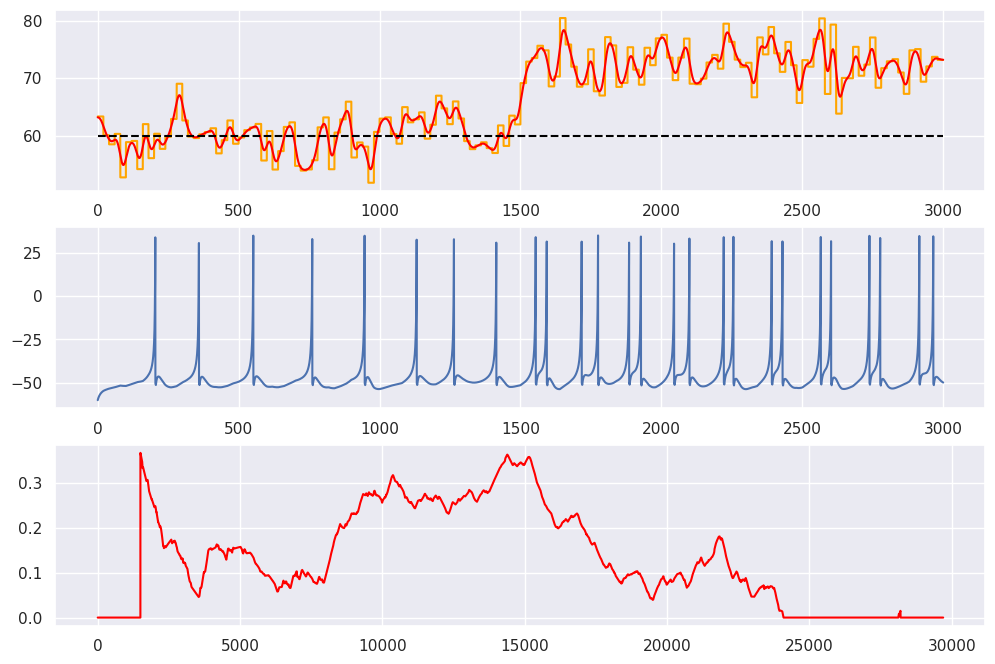

In [ ]:
fig, ax = plt.subplots(3, 1, figsize = (12, 8))

fluss_detector = FLUSS(window_length = 300)
f_target = 225
v_target = 12.5
h_target = 12
idx = find_idx(f_target, v_target, h_target, f_values, var, d_H)

ax[0].plot(t, I_inj[idx, :], c ='orange')
ax[0].plot(t, gaussian_filter(I_inj[idx, :], sigma = 100), c ='red')
ax[0].hlines(y = 60, xmin = 0, xmax = 3000, color = 'black', linestyle = '--')

ax[1].plot(t, X[idx, 0, :])

score = fluss_detector.transform(X[idx, 0, :])
ax[2].plot(score, c = 'red')



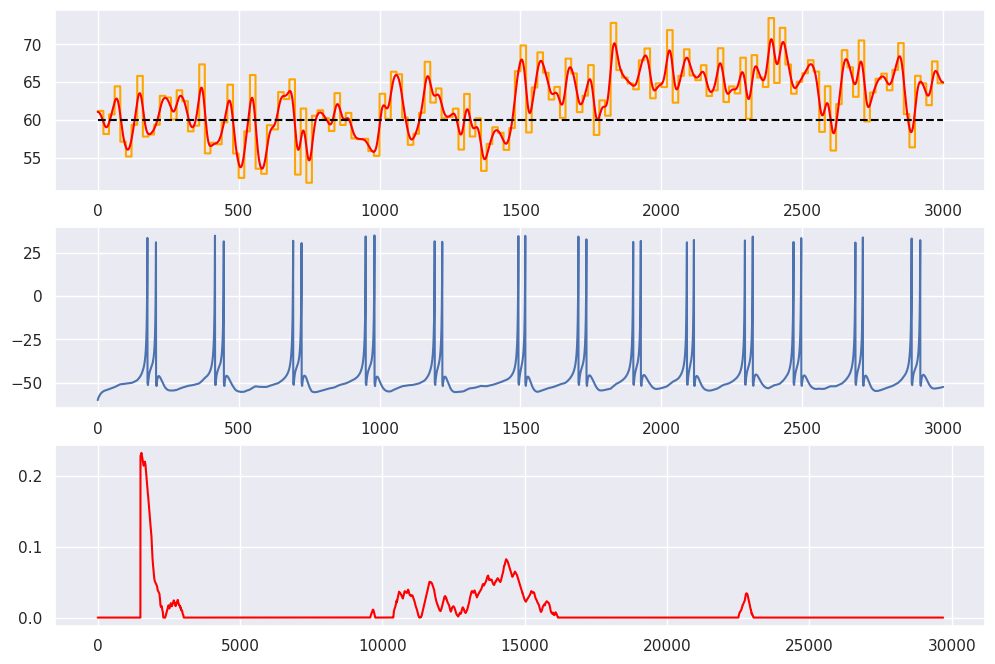

In [ ]:
fig, ax = plt.subplots(3, 1, figsize = (12, 8))

fluss_detector = FLUSS(window_length = 300)
f_target = 300
v_target = 12.5
h_target = 12
idx = find_idx(f_target, v_target, h_target, f_values, var, d_H)

ax[0].plot(t, I_inj[idx, :], c ='orange')
ax[0].plot(t, gaussian_filter(I_inj[idx, :], sigma = 100), c ='red')
ax[0].hlines(y = 60, xmin = 0, xmax = 3000, color = 'black', linestyle = '--')

ax[1].plot(t, X[idx, 0, :])

score = fluss_detector.transform(X[idx, 0, :])
ax[2].plot(score, c = 'red')

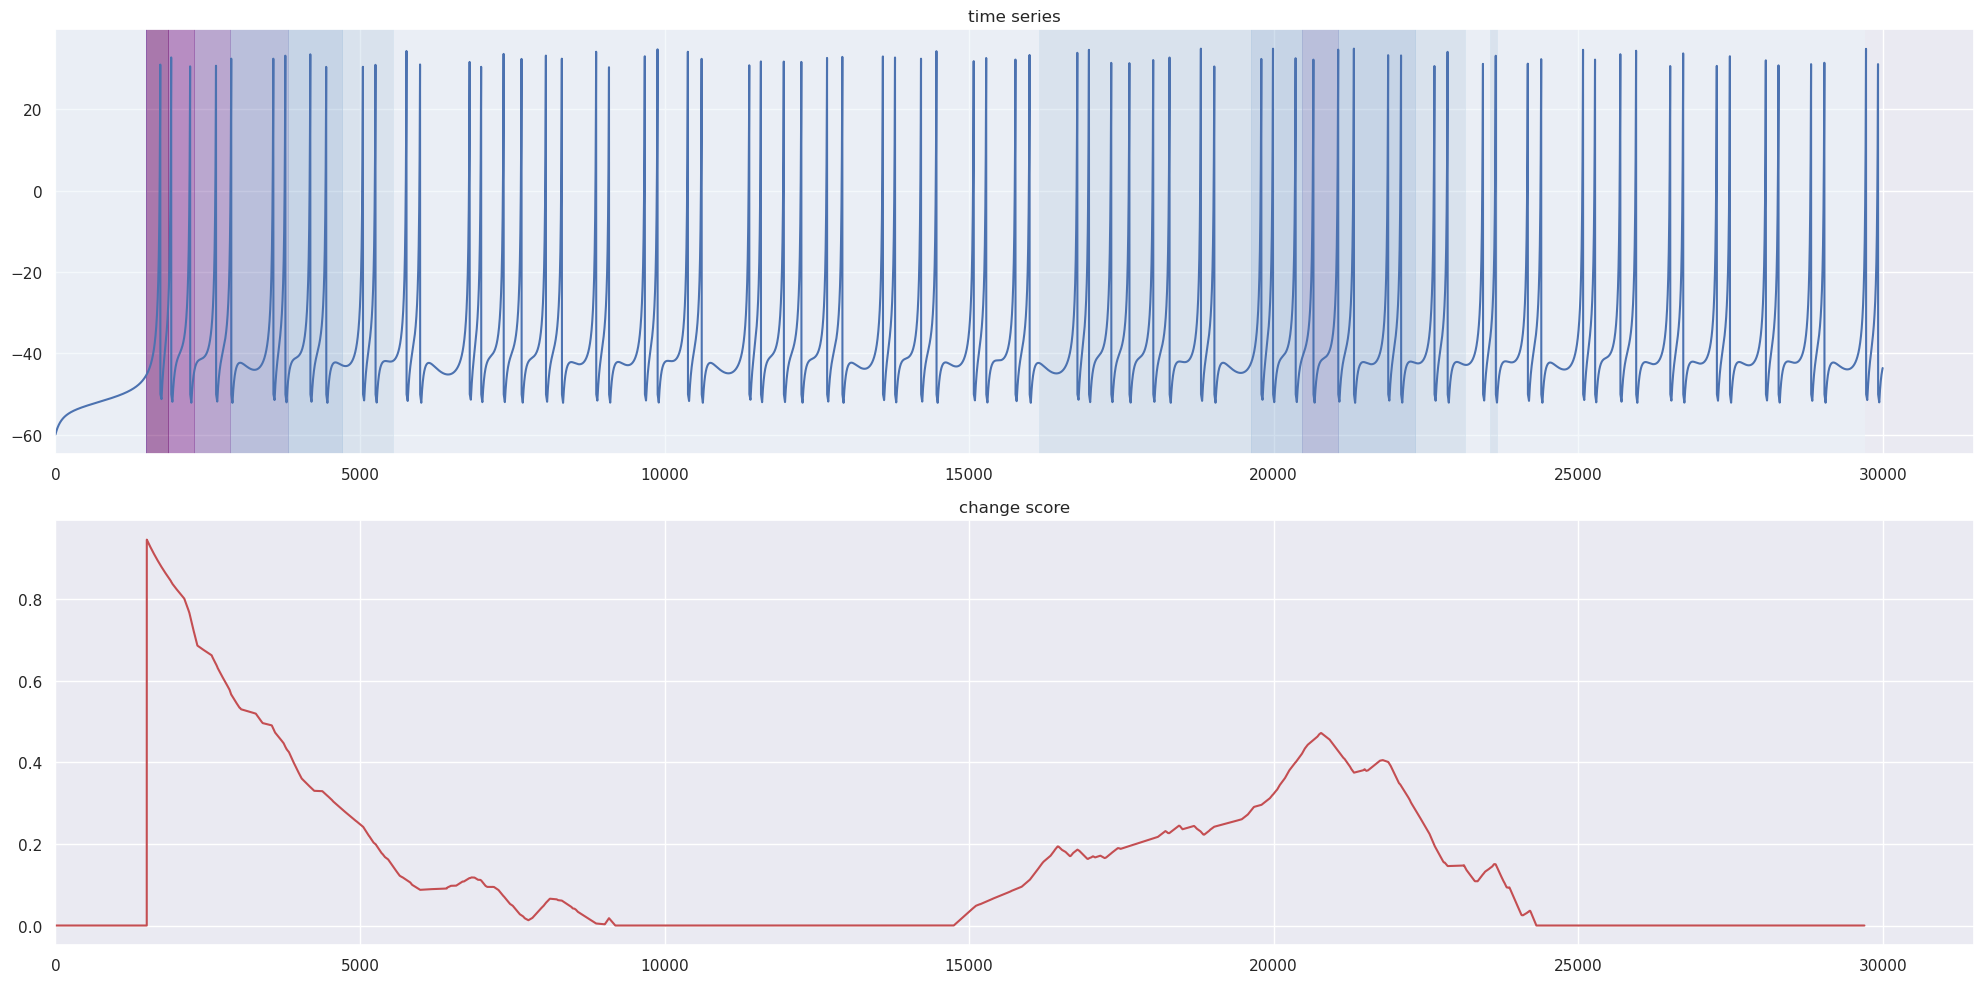

In [185]:
fluss_detector = FLUSS(window_length = 300)

idx = find_idx(400, 0, 0, f_values, var, d_H)
score_raw_aut = fluss_detector.transform(X[idx, 0, :])

plot_data_and_score(X[idx, 0, :], score_raw_aut)
plt.gcf().tight_layout()